In [114]:
import numpy as np
import jax
import jax.scipy as jsp
import jax.numpy as jnp
from jax import config
import jax_healpy as jhp
import matplotlib.pyplot as plt
import healpy as hp
import toml
from functools import partial
config.update("jax_enable_x64", True)

import lineax as lx
import micmac 

from micmac.toolbox.tools import (
    transform_alms_shape,
)

In [115]:
from os import cpu_count
import numpy as np
import healpy as hp
import ducc0



def _ducc_dictionary(
        spin, 
        nside, 
        lmax, 
        mmax=None):
    
    ducc_healpix_obj = ducc0.healpix.Healpix_Base(nside, 'RING')
    if mmax is None:
        mmax = lmax
    # m_array = np.arange(mmax + 1)
    return {'spin': spin,
              'lmax': lmax, 
              'mmax': mmax,
            #   'mstart': (m_array*(2*lmax+1-m_array)//2).astype(np.uint64, copy=False), 
              **ducc_healpix_obj.sht_info()
    }

def _alm2map_ducc0(alms, spin, nside, lmax=None, mmax=None, nthreads=-1):

    if nthreads < 0:
        nthreads = cpu_count()

    if alms.ndim > 1:
        alm_size = alms.shape[-1]
    else:
        alm_size = alms.size
    if lmax is None:
        lmax = hp.Alm.getlmax(alms.shape[-1])
    else:
        assert lmax <= hp.Alm.getlmax(alms.shape[-1]), (lmax, hp.Alm.getlmax(alms.shape[-1]))
    if mmax is None:
        mmax = lmax

    maps = ducc0.sht.synthesis(
        alm=np.atleast_2d(alms),
        nthreads=nthreads,
        **_ducc_dictionary(
            spin, 
            nside, 
            lmax, 
            mmax, 
        )
    )
    return maps


def _map2alm_ducc0(maps, spin, lmax=None, mmax=None, nthreads=-1):

    nside = hp.npix2nside(maps.shape[-1])
    
    if lmax is None:
        lmax = 3 * nside - 1

    if mmax is None:
        mmax = lmax

    if nthreads < 0:
        nthreads = cpu_count()

    weight = 4*np.pi/(12 * nside**2)
    alm = ducc0.sht.adjoint_synthesis(
        map=np.atleast_2d(maps) * weight, 
        nthreads=nthreads,
        **_ducc_dictionary(
            spin, 
            nside, 
            lmax, 
            mmax, 
        )
    )
    return alm

def map2alm_ducc0_iter(maps, spin, lmax=None, mmax=None, niter=3):
    nside = hp.npix2nside(maps.shape[-1])

    alms_output = _map2alm_ducc0(maps, spin=spin, lmax=lmax, mmax=mmax)

    for iter_ in range(niter):
        residual_map = _alm2map_ducc0(alms_output, spin=spin, nside=nside, lmax=lmax, mmax=mmax) - maps
        alms_output -= _map2alm_ducc0(residual_map, spin=spin, lmax=lmax, mmax=mmax)
    return alms_output

In [116]:
def redcom_cov_frequency_almxfl_2D(alms, fl, lmax, lmin):
    assert fl.shape[0] == lmax - lmin + 1
    assert alms.shape[-1] == (lmax + 1)*(lmax//2 + 1)
    assert alms.shape[0] == fl.shape[1]
    assert alms.shape[1] == fl.shape[2]
    alms_2D = transform_alms_shape(alms, lmax = lmax, transformation = "healpix_to_2dlm")
    zero_pad = jnp.repeat(jnp.zeros_like(alms_2D[:,:,0,:])[:,:,np.newaxis,:], 2, axis = 2)
    alms_2D_result = jnp.concatenate((zero_pad, jnp.einsum("fsLm, Lfset -> etLm", alms_2D[..., lmin:, :], fl)), axis = 2)
    alms_result = transform_alms_shape(alms_2D_result, lmax = lmax, transformation = "2dlm_to_healpix")
    return alms_result

def red_cov_frequency_almxfl_2D(alms, fl, lmax, lmin):
    assert fl.shape[0] == lmax - lmin + 1
    assert alms.shape[-1] == (lmax + 1)*(lmax//2 + 1)
    assert alms.shape[0] == fl.shape[1]
    alms_2D = transform_alms_shape(alms, lmax = lmax, transformation = "healpix_to_2dlm")
    zero_pad = jnp.repeat(jnp.zeros_like(alms_2D[:,0,:])[:,np.newaxis,:], 2, axis = 1)
    alms_2D_result = jnp.concatenate((zero_pad, jnp.einsum("sLm, Lst -> tLm", alms_2D[..., lmin:, :], fl)), axis = 1)
    alms_result = transform_alms_shape(alms_2D_result, lmax = lmax, transformation = "2dlm_to_healpix")
    return alms_result

def alms_x_redcom_covariance_pixel_ducc0_JAX(alms, red_pixel_covariance, spin, nside, lmax, n_iter=3):
    """
    Return alms convolved with the pixel covariance matrix given as input
    in the format [n_pix, n_components, nstokes, n_components, nstokes], assuming it's block diagonal

    The input matrix have to start from ell=lmin, otherwise the lmax associated with the harmonic
    operations will be wrong

    Parameters
    ----------
    component_alms: array[float] of shape [n_components, nstokes, n_alms]
         input maps
    red_matrix_sqrt: array[float] of shape [n_pix, n_components, nstokes, n_components, nstokes]
        input reduced spectra
    nside: int
        nside of the input maps
    lmax: int
        maximum ell for the spectrum
    n_iter: int
        number of iterations for harmonic operations

    Returns
    -------
    maps_output: array[float] of shape [n_components, nstokes, n_alms]
        input maps convolved with input spectra
    """
    nstokes = alms.shape[0]

    def wrapper_map2alm_ducc0(maps_, spin=spin, lmax=lmax, n_iter=n_iter, nside= nside):
        maps_np = jax.tree.map(np.asarray, maps_).reshape((2, 12 * nside**2))
        alm_E, alm_B = map2alm_ducc0_iter(maps_np, spin=spin, lmax=lmax, niter=n_iter)
        return np.array([alm_E, alm_B])

    # Wrapper for alm2map, to prepare the pure callback of JAX
    def wrapper_alm2map_ducc0(alm_, spin=spin, lmax=lmax, nside=nside):
        alm_np = jax.tree.map(np.asarray, alm_)
        return _alm2map_ducc0(alm_np, spin=spin, nside=nside, lmax=lmax)

    # Pure call back of map2alm, to be used with JAX for JIT compilation
    @partial(jax.jit, static_argnums=(1, 2, 3))
    def pure_call_map2alm_ducc0(maps_, spin=spin, lmax=lmax, nside=nside):
        shape_output = (2, (lmax + 1) * (lmax // 2 + 1))
        
        return jax.pure_callback(
            wrapper_map2alm_ducc0,
            jax.ShapeDtypeStruct(shape_output, np.complex128),
            maps_.ravel(),
        )

    @partial(jax.jit)
    def pure_call_alm2map_ducc0(alm_):
        shape_output = (2, 12 * nside**2)
        return jax.pure_callback(wrapper_alm2map_ducc0, jax.ShapeDtypeStruct(shape_output, np.float64), alm_)

    maps_QU = pure_call_alm2map_ducc0(alms)
    maps_output = maps_QU*red_pixel_covariance
    alms_output = pure_call_map2alm_ducc0(maps_output)
    return alms_output

## Parameters to create the *MICMAC* object

In [117]:
dictionary_params = {
    'general': {
        'disable_chex': False, # quick test parameters
        'classical_Gibbs': False, # to not sample for mixing matri alements, and have them fixed to their initial value 
        'bf_sampling': {
            'perturbation_eta_covariance': True,  # !! keep true to have optimized version for the Bf sampling -- needs step size Bf low enough
            'simultaneous_accept_rate': False,     # !! keep true to have optimized version for the Bf sampling with multipatch -- assumes noise to be uncorrelated between patches
            'use_alternative_Bf_sampling': False, # to use the alternative Bf sampling, which is more efficient for the sampling of Bf, to use - d^t N^{-1} B (B^t N^{-1} B)^{-1} B^t N^{-1} d + (s_c - s_c,ML)^t N_c^-1 (s_c - s_c,ML)
            # instead of - (d - B_c s_c)^t N^{-1} B 
        },
        'eta_sampling': {
            'biased_version': False, # to sample without the eta term in the Bf sampling 
            'suppress_low_modes': True, # to make eta band-limited 
            'use_mask_contribution_eta': True # to account for the mask in the computation of the noise contribution to the covariance of eta
        }
    },
    'scam': {
        'use_scam_step_size': True, # to use the step-size provided in the file, instead of the one provided in the toml file
        'burn_in_scam': 50, # Number of iterations for the burn-in before the adaptive step-size for the Metropolis-Hastings-within-Gibbs sampling of r and Bf
        'scam_iteration_updates': 40 # Number of iterations corresponding to the rate of update of the step-size for the Metropolis-Hastings-within-Gibbs sampling of r and Bf
    },
    'setup': {
        'nside': 32,
        'lmax': 64,
        'nstokes': 2,
        'lmin': 2,
        'n_iter': 3, # Number of iterations for Python estimation of alms
        'n_components': 3, # Number of components to sample, usually 3 (CMB + 2 foregrounds components)
        'pos_special_freqs': [0, -1], # position of the special frequencies in the frequency array, if not provided, the first and last frequencies will be considered as special frequencies
        'indexes_free_Bf': False, # Bf indexes that will be sampled
        'seed': 42 # seed for the begining of the chain
    },
    'cg_params': {
        'limit_iter_cg': 400, # Maximum number of iterations for the different CG 
        'limit_iter_cg_eta': 400, # Maximum number of iterations for the CG of eta
        'tolerance_CG': 1e-6, # Tolerance for the different CGs
        'atol_CG': 1e-6
    },
    'metropolis': {
        'step_size_Bf_1': 1e-4, # Provide step-size for the first column of Bf ; it can also be provided as a list 
        'step_size_Bf_2': 5e-5 # Provide step-size for the second column of Bf ; it can also be provided as a list 
    },
    'cmb_sampling': {
        'sample_r_Metropolis': True,
        'sample_C_inv_Wishart': False,
        'c_sampling': {
            'non_centered_moves': False,
            'use_binning': False, # WARNING: this option is not implemented yet, and will not work
            'save_intermediary_centered_moves': False,
            # 'binwidth': 1 # binwidth for power spectrum binning
        },
        'r_sampling': {
            'step_size_r': 5e-4, #1e-4 #5e-4 #1e-5 ???
            'limit_r_value': True,
            # 'min_r_value': 0, # default to None, only uncomment if you want to set a minimum value for r 
            'below_0_min_r_value': True, # to allow r to be below 0 while keeping C(r) positive definite
            'use_alm_sampling_r': False, # to sample r using the alms of the CMB map sampled
            'use_alm_sampling_r_wEE': False, # to sample r using the alms of the CMB map sampled
            # 'lmin_BB': 30 #TODO: to put to 30 with mask!!!
        }
    },
    'save_flags': {
        'save_CMB_chain_maps': False, # If true, all the sampled CMB maps which are marginalized over will be saved
        'save_eta_chain_maps': False, # If true, all the sampled eta maps which are marginalized over will be saved
        'save_s_c_spectra': False # If true, the s_c spectra will be saved
    },
    'instrument': {
        'instrument_name': 'SO_SAT' #example: 'LiteBIRD' or 'SO_SAT' # Either provide instrument name, then freq_inverse_noise and frequency_array will be taken from fgbuster,
        # or provide expcitely freq_inverse_noise and frequency_array with instrument_name="customized_instrument"
        # 'frequency_array': [90],
        # 'depth_p': [4]
    }, 
    'iterations': {
        'number_iterations_sampling': 5, #1000 #1500 #5000 #3000 #6000 # 1000 #2000 #5000 #1500 #2500 #300 #700 #1200 #125 #500 #1000 #2000 #400, # Maximum number of iterations for the sampling
        'number_iterations_done': 0, # Number of iterations already accomplished, in case the chain is resuming from a previous run 
    }
}

In [118]:
MICMAC_obj = micmac.create_MicmacSampler_from_dictionnary(dictionary_params, path_file_spv='', transform_to_root_dict=True)

Loading or creating the spv config from a yaml file
No spatial variability case

>>> Tree of spv config as passed by the User:
root
  nside_spv
    default: [0]
    f0
      default: None
      b0
        default: None
      b1
        default: None
      b2
        default: None
      b3
        default: None
    f1
      default: None
      b0
        default: None
      b1
        default: None
      b2
        default: None
      b3
        default: None

>>> Tree of spv config after filling the missing values:
root
  nside_spv
    default: [0]
    f0
      default: [0]
      b0
        default: [0]
      b1
        default: [0]
      b2
        default: [0]
      b3
        default: [0]
    f1
      default: [0]
      b0
        default: [0]
      b1
        default: [0]
      b2
        default: [0]
      b3
        default: [0]
Templates created [[[0 0 0 ... 0 0 0]
  [4 4 4 ... 4 4 4]]

 [[1 1 1 ... 1 1 1]
  [5 5 5 ... 5 5 5]]

 [[2 2 2 ... 2 2 2]
  [6 6 6 ... 6 6 6]]

 [[3 3 3 

In [119]:
spin = 2
nside = MICMAC_obj.nside
lmax = MICMAC_obj.lmax
n_iter = 10

def wrapper_map2alm_ducc0(maps_, spin=spin, lmax=lmax, n_iter=n_iter, nside= nside):
    maps_np = jax.tree.map(np.asarray, maps_).reshape((2, 12 * nside**2))
    alm_E, alm_B = map2alm_ducc0_iter(maps_np, spin=spin, lmax=lmax, niter=n_iter)
    return np.array([alm_E, alm_B])

# Wrapper for alm2map, to prepare the pure callback of JAX
def wrapper_alm2map_ducc0(alm_, spin=spin, lmax=lmax, nside=nside):
    alm_np = jax.tree.map(np.asarray, alm_)
    return _alm2map_ducc0(alm_np, spin=spin, nside=nside, lmax=lmax)

# Pure call back of map2alm, to be used with JAX for JIT compilation
@partial(jax.jit, static_argnums=(1, 2, 3))
def pure_call_map2alm_ducc0(maps_, spin=spin, lmax=lmax, nside=nside):
    shape_output = (2, (lmax + 1) * (lmax // 2 + 1))

    return jax.pure_callback(
        wrapper_map2alm_ducc0,
        jax.ShapeDtypeStruct(shape_output, np.complex128),
        maps_.ravel(),
    )

@partial(jax.jit)
def pure_call_alm2map_ducc0(alm_):
    shape_output = (2, 12 * nside**2)
    return jax.pure_callback(wrapper_alm2map_ducc0, jax.ShapeDtypeStruct(shape_output, np.float64), alm_)

## Retrieving the mask

np.float32(0.10091146)

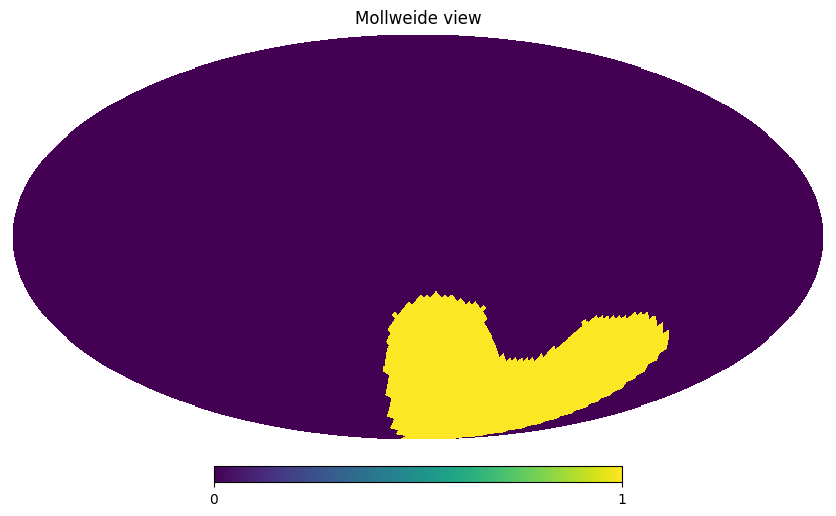

In [120]:
#mask = np.ones(MICMAC_obj.n_pix, dtype=float)

#mask = hp.ud_grade(np.load(f"masks/mask_60.npy"), nside_out = nside)
mask = hp.ud_grade(hp.read_map(f"masks/mask_SO_SAT_apodized.fits", field = 0), nside_out = MICMAC_obj.nside)
mask[mask > 0.3] = 1.0
mask[mask < 0.3] = 0

phi_ang, theta_ang = hp.pix2ang(MICMAC_obj.nside, np.arange(mask.size), lonlat=True)
mask[theta_ang>0] = 0

mask_indices = np.where(mask > 0)[0]
npix_mask = int(mask.sum())

hp.mollview(mask)

f_sky = mask.sum() / mask.size
f_sky 

In [121]:
ell_range = jnp.arange(MICMAC_obj.lmin, MICMAC_obj.lmax + 1)

## Preparing input maps

In [122]:
r_true = 1e-3

In [123]:
seed = 42 

In [124]:
np.random.seed(seed)
freq_maps_foregrounds = micmac.get_observation('SO_SAT', 'd0s0', nside=MICMAC_obj.nside, noise=False)[
    :, 1:, :
]  # keep only Q and U

['d0', 's0']


In [125]:
np.random.seed(seed+1)
(
    freq_maps,
    input_cmb_maps,
    theoretical_red_cov_r0_total,
    theoretical_red_cov_r1_tensor,
) = MICMAC_obj.generate_input_freq_maps_from_fgs(
    freq_maps_foregrounds, 
    r_true=r_true, 
    lmin_input=MICMAC_obj.lmin,
    return_only_freq_maps=False)

freq_maps = freq_maps * mask

Setting lmin to  2
Calculating spectra from CAMB !
Calculating spectra from CAMB !


In [126]:
init_mixing_matrix_obj = micmac.InitMixingMatrix(
    freqs=MICMAC_obj.frequency_array,
    ncomp=MICMAC_obj.n_components,
    pos_special_freqs=MICMAC_obj.pos_special_freqs,
    templates=MICMAC_obj.templates,
)
exact_params_mixing_matrix = init_mixing_matrix_obj.init_params()
exact_params_mixing_matrix

>>> init params built with spectral params: 1.54 20.0 -3.0


array([0.33858815, 0.02963068, 0.00998213, 0.00328725, 0.00979233,
       0.05147511, 0.12913911, 0.44076761])

## Preparing intermediaries (mixing matrix to use, noise covariance, ...)

In [127]:
params_mixing_matrix_sample = jnp.copy(exact_params_mixing_matrix)

mixing_matrix_sampled = MICMAC_obj.get_B_from_params(params_mixing_matrix_sample, jax_use=True) * mask

red_cov_matrix_sqrt = micmac.get_sqrt_reduced_matrix_from_matrix_jax(
    theoretical_red_cov_r0_total + r_true * theoretical_red_cov_r1_tensor
)

In [128]:
instrument = micmac.get_instrument(MICMAC_obj.instrument_name)

freq_inverse_noise = micmac.get_noise_covar_extended(
    instrument['depth_p'], MICMAC_obj.nside
)  # MICMAC_obj.freq_inverse_noise

MICMAC_obj.freq_inverse_noise = freq_inverse_noise * mask

N_c = micmac.get_inv_BtinvNB(MICMAC_obj.freq_inverse_noise, mixing_matrix_sampled, jax_use=True)[0,0,:] * hp.nside2resol(MICMAC_obj.nside) ** 2

invBtinvNB = micmac.get_inv_BtinvNB(MICMAC_obj.freq_inverse_noise, mixing_matrix_sampled, jax_use=True) * hp.nside2resol(MICMAC_obj.nside) ** 2

BtinvN_sqrt = micmac.get_BtinvN(jnp.sqrt(MICMAC_obj.freq_inverse_noise), mixing_matrix_sampled, jax_use=True)

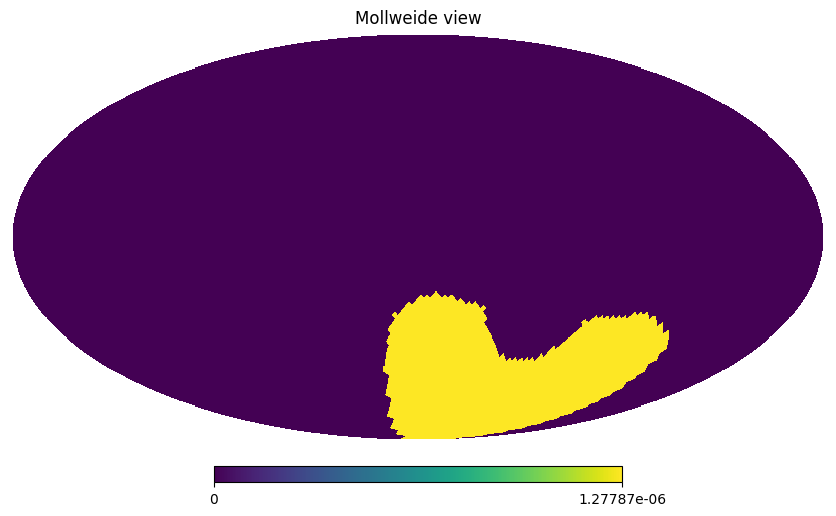

In [129]:
hp.mollview(N_c)

## Preparing right hand side terms

### Fluctuation right hand side 

In [130]:
jax_key_PNRG = jax.random.PRNGKey(seed+2)

jax_key_PNRG, jax_key_PNRG_xi = jax.random.split(jax_key_PNRG)  # Splitting of the random key to generate a new one

print('Recalculating xi !')
map_random_realization_xi = jax.random.normal(
    jax_key_PNRG_xi, shape=(MICMAC_obj.nstokes, MICMAC_obj.n_pix)
) / jhp.nside2resol(MICMAC_obj.nside)

jax_key_PNRG, *jax_key_PNRG_chi = jax.random.split(
    jax_key_PNRG, MICMAC_obj.n_frequencies + 1
)  # Splitting of the random key to generate a new one
# If no random maps are provided, then it is computed within the routine
print('Recalculating chi !')

def fmap(random_key):
    random_map = jax.random.normal(random_key, shape=(MICMAC_obj.nstokes, MICMAC_obj.n_pix))
    # return MICMAC_obj.get_band_limited_maps(random_map)
    return random_map

map_random_realization_chi = jax.vmap(fmap)(
    jnp.array(jax_key_PNRG_chi)
)  # Generating a different random Gaussian map for each frequency


# Computation of the right side member of the CG

# First right member: xi
right_member_1 = map_random_realization_xi

# Second right member:
## Computation of C^{1/2} N_c^{-1/2} \chi
N_c_inv = jnp.copy(N_c)
N_c_inv = N_c_inv.at[..., mask != 0].set(
    1 / N_c[mask != 0] / jhp.nside2resol(MICMAC_obj.nside) ** 2
)
N_c_inv_repeat = jnp.broadcast_to(N_c_inv, (MICMAC_obj.nstokes, MICMAC_obj.n_pix)).ravel()
# Repeat N_c_inv for each Stokes parameter, for speed-up afterwards

## Computation of N_c^{-1/2} \chi = (E^t (B^t N^{-1} B)^{-1} E) E^t (B^t N^{-1} B)^{-1} B^t N^{-1/2} \chi
right_member_2_part = (
    jnp.einsum('kcp,cfp,fsp->ksp', invBtinvNB, BtinvN_sqrt , map_random_realization_chi)[0] * N_c_inv
)  # [0] for selecting CMB component of the random variable
# First compute N_c^{-1/2} \chi
right_member_2 = micmac.maps_x_red_covariance_cell_JAX(
    right_member_2_part, red_cov_matrix_sqrt, nside=MICMAC_obj.nside, lmin=MICMAC_obj.lmin, n_iter=MICMAC_obj.n_iter
)
# Then apply C^{1/2} to N_c^{-1/2} \chi

# right_member = (right_member_1 + right_member_2).ravel()
# right_member_fluctuation = (MICMAC_obj.get_band_limited_maps(right_member_1).ravel() + right_member_2.ravel()).reshape(-1, MICMAC_obj.n_pix)

right_member_fluctuation = MICMAC_obj.get_band_limited_maps(right_member_1) + right_member_2


Recalculating xi !
Recalculating chi !


In [131]:
N_c_inv

Array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       0.00000000e+00, 7.65217494e+08, 7.65217494e+08], dtype=float64)

### WF right hand side 

In [132]:
## Preparation of the right member of the CG
s_cML = micmac.get_Wd(freq_inverse_noise, mixing_matrix_sampled, freq_maps, jax_use=True)[0]

right_member_WF = micmac.maps_x_red_covariance_cell_JAX(
            s_cML * N_c_inv , red_cov_matrix_sqrt, nside=MICMAC_obj.nside, lmin=MICMAC_obj.lmin, n_iter=MICMAC_obj.n_iter
)


### Total right hand side term

In [133]:
right_member = right_member_fluctuation + right_member_WF
right_member.shape

(2, 12288)

In [134]:
right_member_alms = pure_call_map2alm_ducc0(right_member)
right_member_alms.shape

(2, 2145)

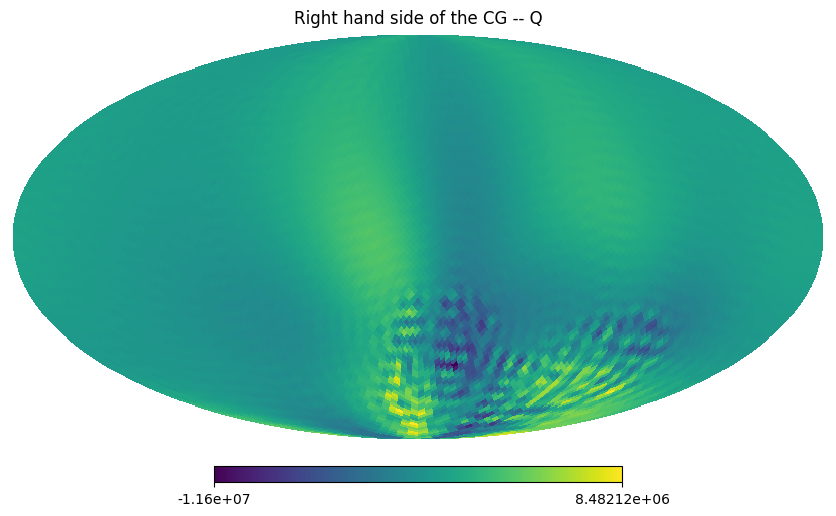

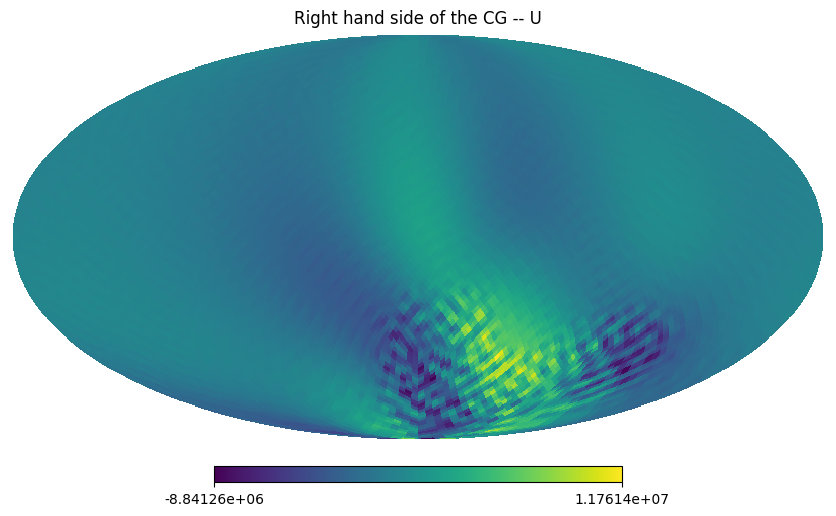

In [135]:
hp.mollview(right_member[0], title='Right hand side of the CG -- Q')
hp.mollview(right_member[1], title='Right hand side of the CG -- U')

## Prepare the system matrix $(1 + C^{1/2} N^{-1} C^{1/2})$

In [136]:
# Building N_c^{-1} and padding 0 outside the obserevd area
N_c_inv = jnp.zeros_like(N_c)
N_c_inv = N_c_inv.at[..., mask != 0].set(1 / N_c[mask != 0]  / jhp.nside2resol(MICMAC_obj.nside) ** 2)
N_c_inv_repeat = jnp.broadcast_to(
    N_c_inv, (MICMAC_obj.nstokes, MICMAC_obj.n_pix)
).ravel()  ## Repeat N_c_inv for each Stokes parameter, for speed-up afterwards

# N_c_inv_mask_indices = jnp.zeros(mask_indices, dtype=float)
N_c_inv_mask_indices = 1. / N_c[mask != 0]
N_c_inv_mask_indices_repeat = jnp.broadcast_to(
    N_c_inv_mask_indices, (MICMAC_obj.nstokes, npix_mask)
).ravel()  ## Repeat N_c_inv for each Stokes parameter, for speed-up afterwards


## Preparing the operator C_approx^{1/2}
first_part_left = lambda x: micmac.maps_x_red_covariance_cell_JAX(
    x.reshape((MICMAC_obj.nstokes, MICMAC_obj.n_pix)),
    red_cov_matrix_sqrt,
    nside=MICMAC_obj.nside,
    lmin=MICMAC_obj.lmin,
    n_iter=MICMAC_obj.n_iter,
).ravel()

## Preparing the operator N_c^{-1}
def second_part_left(x):
    return x * N_c_inv_repeat


In [137]:
## Second left member pixel operator: (E^t (B^t N^{-1} B)^{-1} E) x
n_lms = (lmax + 1) * (lmax // 2 + 1)
first_part_left_alms = lambda x: red_cov_frequency_almxfl_2D(
    x.reshape((MICMAC_obj.nstokes, n_lms)),
    red_cov_matrix_sqrt,
    lmax = MICMAC_obj.lmax,
    lmin = MICMAC_obj.lmin,
).ravel()

def second_part_left_alms(x):
    return alms_x_redcom_covariance_pixel_ducc0_JAX(
        x.reshape((MICMAC_obj.nstokes, n_lms)), 
        N_c_inv_repeat.reshape((MICMAC_obj.nstokes, MICMAC_obj.n_pix)),
        spin = 2,
        nside = MICMAC_obj.nside,
        lmax = MICMAC_obj.lmax,
    ).ravel()


In [138]:
N_c_inv_repeat.shape

(24576,)

In [139]:
func_left_term = lambda x: x.ravel() + first_part_left(second_part_left(first_part_left(x))).ravel()
func_left_term_alms = lambda x: x.ravel() + first_part_left_alms(second_part_left_alms(first_part_left_alms(x))).ravel()

func_lineax = lx.FunctionLinearOperator(
    func_left_term, 
    input_structure=jax.ShapeDtypeStruct((MICMAC_obj.nstokes*MICMAC_obj.n_pix,),jnp.float64), 
    tags=(lx.positive_semidefinite_tag, lx.symmetric_tag)
)


func_lineax_alms = lx.FunctionLinearOperator(
    func_left_term_alms, 
    input_structure=jax.ShapeDtypeStruct((MICMAC_obj.nstokes*n_lms,),jnp.complex128), 
    tags=(lx.positive_semidefinite_tag, lx.symmetric_tag)
)

### Preparing a preconditioner corresponding to simply an inverse of the equivalent system matrix in harmonic domain

In [140]:
 ## Assuming a harmonic noise with the pixel average of the mixing matrix

freq_noise_c_ell = micmac.get_true_Cl_noise(np.array(instrument['depth_p']), MICMAC_obj.lmax) 

noise_c_ell = micmac.get_inv_BtinvNB_c_ell(freq_noise_c_ell, mixing_matrix_sampled.mean(axis=2))[0, 0, MICMAC_obj.lmin:]

#noise_c_ell = micmac.noisecovar.get_Cl_noise_JAX(np.array(instrument['depth_p']), np.mean(mixing_matrix_sampled, axis = 2), lmax = lmax)[0,0,MICMAC_obj.lmin:]
## Getting N_c^{-1} for the harmonic noise covariance
red_inv_noise_c_ell = jnp.linalg.pinv(
    micmac.get_reduced_matrix_from_c_ell_jax(
        jnp.stack([noise_c_ell, noise_c_ell, jnp.zeros_like(noise_c_ell)])
    )
) 

red_preconditioner_s_c = jnp.linalg.pinv(
    jnp.eye(MICMAC_obj.nstokes)
    + jnp.einsum('lij,ljk,lkm->lim', red_cov_matrix_sqrt, red_inv_noise_c_ell, red_cov_matrix_sqrt) 
) 

precond_func = lambda x: micmac.maps_x_red_covariance_cell_JAX(
    x.reshape((MICMAC_obj.nstokes, MICMAC_obj.n_pix)),
    red_preconditioner_s_c,
    nside=MICMAC_obj.nside,
    lmin=MICMAC_obj.lmin,
    n_iter=MICMAC_obj.n_iter,
).ravel()

In [141]:
precond_func_alms = lambda x: red_cov_frequency_almxfl_2D(
    x.reshape((MICMAC_obj.nstokes, n_lms)),
    red_preconditioner_s_c,
    lmax = MICMAC_obj.lmax,
    lmin = MICMAC_obj.lmin,
).ravel()

In [142]:
max_iter_CG = 10000 #200 #400

tolerance_CG = 1e-6

In [143]:
## Preparation of the initial guess
initial_guess = jnp.copy(right_member)

In [144]:
solver = lx.CG(rtol=tolerance_CG, atol=tolerance_CG, max_steps=max_iter_CG, norm=lx._norm.rms_norm,)
throw = False


options = dict()
options['y0'] = jnp.zeros_like(initial_guess.ravel())


options_w_precond = dict()

options_w_precond['y0'] = jnp.zeros_like(initial_guess.ravel())
options_w_precond['preconditioner'] = lx.FunctionLinearOperator(
    precond_func, 
    input_structure=jax.ShapeDtypeStruct((MICMAC_obj.nstokes*MICMAC_obj.n_pix,),jnp.float64), 
    tags=(lx.positive_semidefinite_tag, lx.symmetric_tag)
)

In [145]:
%%time
result_sp_z, iterations = jsp.sparse.linalg.cg(
    func_left_term,
    right_member.ravel(),
    x0=jnp.zeros_like(initial_guess.ravel()),
    tol=tolerance_CG,
    maxiter=max_iter_CG,
)

result_sp_z = result_sp_z.reshape((MICMAC_obj.nstokes, MICMAC_obj.n_pix))
jax.block_until_ready(result_sp_z)

result_sp = micmac.maps_x_red_covariance_cell_JAX(
    result_sp_z,
    red_cov_matrix_sqrt,
    nside=MICMAC_obj.nside,
    lmin=MICMAC_obj.lmin,
    n_iter=MICMAC_obj.n_iter,)

CPU times: user 5min 49s, sys: 54.8 s, total: 6min 44s
Wall time: 1min 12s


In [146]:
%%time

solution = lx.linear_solve(func_lineax, right_member.ravel(), solver=solver, throw=throw, options=options)
print("solved in", solution.stats['num_steps'], "steps")
result_lineax_z = solution.value.reshape((MICMAC_obj.nstokes, MICMAC_obj.n_pix))
result_lineax = micmac.maps_x_red_covariance_cell_JAX(
    result_lineax_z,
    red_cov_matrix_sqrt,
    nside=MICMAC_obj.nside,
    lmin=MICMAC_obj.lmin,
    n_iter=MICMAC_obj.n_iter,
)

solved in 10000 steps
CPU times: user 10min 19s, sys: 1min 35s, total: 11min 55s
Wall time: 2min 11s


In [147]:
%%time
result_sp_w_precond_z, iterations_w_precond = jsp.sparse.linalg.cg(
    func_left_term,
    right_member.ravel(),
    x0=initial_guess.ravel(),
    tol=tolerance_CG,
    maxiter=max_iter_CG,
    M=precond_func,
)

result_sp_w_precond_z = result_sp_w_precond_z.reshape((MICMAC_obj.nstokes, MICMAC_obj.n_pix))
jax.block_until_ready(result_sp_w_precond_z)
result_sp_w_precond = micmac.maps_x_red_covariance_cell_JAX(
    result_sp_w_precond_z,
    red_cov_matrix_sqrt,
    nside=MICMAC_obj.nside,
    lmin=MICMAC_obj.lmin,
    n_iter=MICMAC_obj.n_iter,
)

CPU times: user 14min 5s, sys: 2min 10s, total: 16min 15s
Wall time: 2min 59s


In [148]:
%%time

solution_w_precond = lx.linear_solve(func_lineax, right_member.ravel(), solver=solver, throw=throw, options=options_w_precond)
print("solved in", solution_w_precond.stats['num_steps'], "steps")
result_lineax_w_precond_z = solution_w_precond.value.reshape((MICMAC_obj.nstokes, MICMAC_obj.n_pix))
result_lineax_w_precond = micmac.maps_x_red_covariance_cell_JAX(
    result_lineax_w_precond_z,
    red_cov_matrix_sqrt,
    nside=MICMAC_obj.nside,
    lmin=MICMAC_obj.lmin,
    n_iter=MICMAC_obj.n_iter,
)

solved in 10000 steps
CPU times: user 15min 8s, sys: 2min 18s, total: 17min 26s
Wall time: 3min 12s


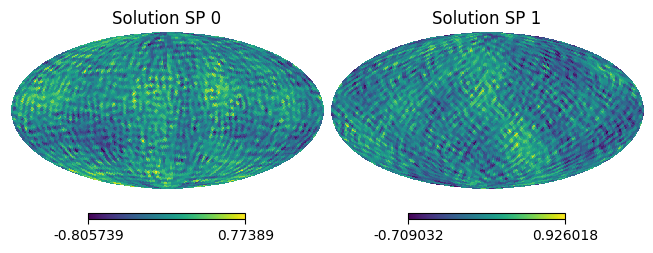

In [149]:
for i in range(MICMAC_obj.nstokes):
    hp.mollview(
        result_sp[i],
        title=f'Solution SP {i}',
        sub=(1, MICMAC_obj.nstokes, i + 1),
        )

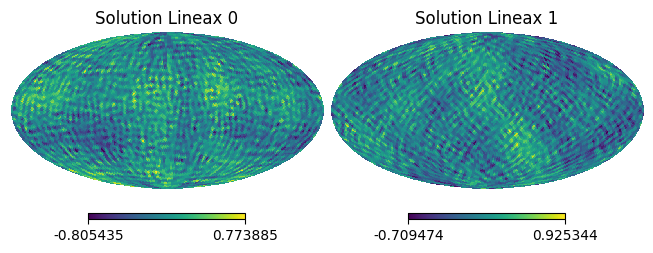

In [150]:
for i in range(MICMAC_obj.nstokes):
    hp.mollview(
        result_lineax[i],
        title=f'Solution Lineax {i}',
        sub=(1, MICMAC_obj.nstokes, i + 1),
        )

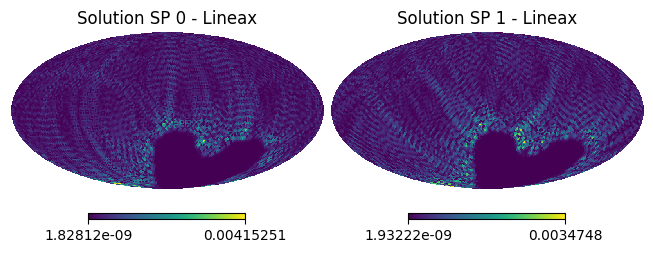

In [151]:
for i in range(MICMAC_obj.nstokes):
    hp.mollview(
        np.abs(result_sp[i]-result_lineax[i]),
        title=f'Solution SP {i} - Lineax',
        sub=(1, MICMAC_obj.nstokes, i + 1),
        )

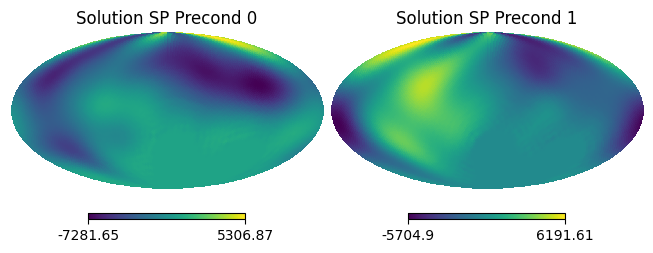

In [152]:
for i in range(MICMAC_obj.nstokes):
    hp.mollview(
        result_sp_w_precond[i],
        title=f'Solution SP Precond {i}',
        sub=(1, MICMAC_obj.nstokes, i + 1),
        )

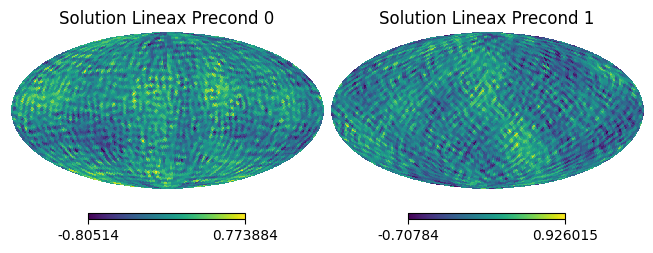

In [153]:
for i in range(MICMAC_obj.nstokes):
    hp.mollview(
        result_lineax_w_precond[i],
        title=f'Solution Lineax Precond {i}',
        sub=(1, MICMAC_obj.nstokes, i + 1),
        )

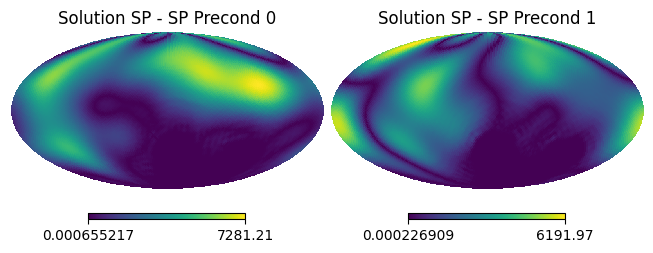

In [154]:
for i in range(MICMAC_obj.nstokes):
    hp.mollview(
        np.abs(result_sp[i] - result_sp_w_precond[i]),
        title=f'Solution SP - SP Precond {i}',
        sub=(1, MICMAC_obj.nstokes, i + 1),
        )

In [155]:
max_iter_CG = 20000 #200 #400
tolerance_CG = 1e-6
initial_guess_alms = jnp.copy(right_member_alms)
solver_alms = lx.CG(rtol=tolerance_CG, atol=tolerance_CG, max_steps=max_iter_CG, norm=lx._norm.rms_norm)
options_alms = dict()
options_alms['y0'] = jnp.zeros_like(initial_guess_alms.ravel())


options_w_precond_alms = dict()

options_w_precond_alms['y0'] = jnp.zeros_like(initial_guess_alms.ravel())
options_w_precond_alms['preconditioner'] = lx.FunctionLinearOperator(
    precond_func_alms, 
    input_structure=jax.ShapeDtypeStruct((MICMAC_obj.nstokes*n_lms,),jnp.complex128), 
    tags=(lx.positive_semidefinite_tag, lx.symmetric_tag)
)


In [156]:
%%time

solution_alms = lx.linear_solve(func_lineax_alms, right_member_alms.ravel(), solver=solver_alms, throw=throw, options=options_alms)
print("solved in", solution_alms.stats['num_steps'], "steps")
result_lineax_alms_z = solution_alms.value.reshape((MICMAC_obj.nstokes, n_lms))
result_lineax_alms = red_cov_frequency_almxfl_2D(
    result_lineax_alms_z,
    red_cov_matrix_sqrt,
    lmax = MICMAC_obj.lmax,
    lmin = MICMAC_obj.lmin,
)

solved in 20000 steps
CPU times: user 3min 33s, sys: 28.2 s, total: 4min 1s
Wall time: 51.9 s


In [157]:
%%time

solution_w_precond_alms = lx.linear_solve(func_lineax_alms, right_member_alms.ravel(), solver=solver_alms, throw=throw, options=options_w_precond_alms)
print("solved in", solution_w_precond_alms.stats['num_steps'], "steps")
result_lineax_w_precond_alms_z = solution_w_precond_alms.value.reshape((MICMAC_obj.nstokes, n_lms))
result_lineax_w_precond_alms = red_cov_frequency_almxfl_2D(
    result_lineax_w_precond_alms_z,
    red_cov_matrix_sqrt,
    lmax = MICMAC_obj.lmax,
    lmin = MICMAC_obj.lmin,
)

solved in 20000 steps
CPU times: user 3min 35s, sys: 28.3 s, total: 4min 3s
Wall time: 53.7 s


In [158]:
result_alms = pure_call_alm2map_ducc0(result_lineax_alms)
result_alms_w_precond = pure_call_alm2map_ducc0(result_lineax_w_precond_alms)

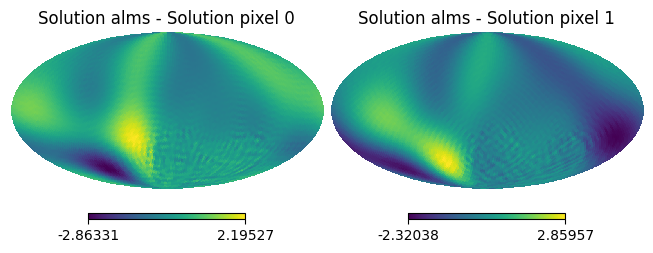

In [159]:
for i in range(MICMAC_obj.nstokes):
    hp.mollview(
        result_alms[i],
        title=f'Solution alms - Solution pixel {i}',
        sub=(1, MICMAC_obj.nstokes, i + 1),
        )

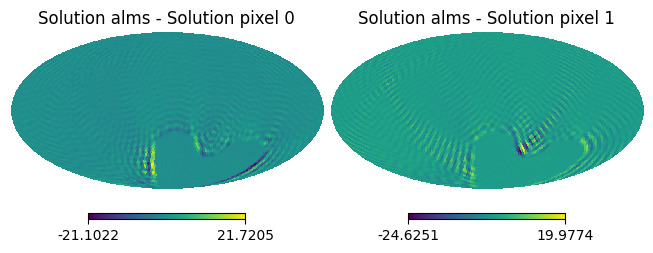

In [160]:
for i in range(MICMAC_obj.nstokes):
    hp.mollview(
        result_alms_w_precond[i],
        title=f'Solution alms - Solution pixel {i}',
        sub=(1, MICMAC_obj.nstokes, i + 1),
        )

In [161]:
def get_cl_from_alms_EB(alms_EB, lmax):
    alms_TEB = np.concatenate((np.zeros_like(alms_EB[0])[np.newaxis], alms_EB), axis = 0)
    return hp.alm2cl(alms_TEB, lmax = lmax)[1:3,2:]
def get_cl_from_maps_QU(maps_QU, lmax):
    maps_TQU = np.concatenate((np.zeros_like(maps_QU[0])[np.newaxis], maps_QU), axis = 0)
    return hp.anafast(maps_TQU, lmax = lmax)[1:3,2:]

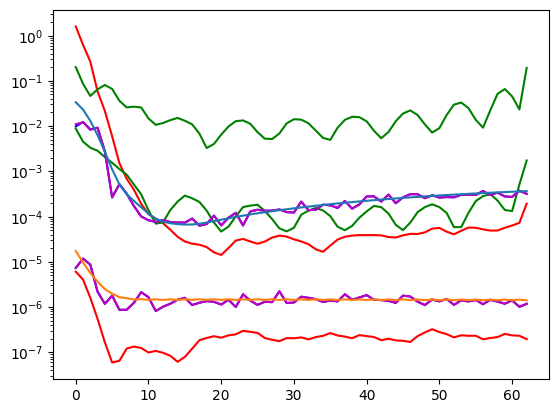

In [162]:
plt.plot(get_cl_from_alms_EB(result_lineax_alms, lmax = lmax).transpose(), "r")
plt.plot(get_cl_from_alms_EB(result_lineax_w_precond_alms, lmax = lmax).transpose(), "g")
plt.plot(get_cl_from_maps_QU(result_lineax_w_precond, lmax = lmax).transpose(), "b")
plt.plot(get_cl_from_maps_QU(result_lineax, lmax = lmax).transpose(), "m")
plt.plot(theoretical_red_cov_r0_total[:,0,0])
plt.plot(theoretical_red_cov_r0_total[:,1,1] + theoretical_red_cov_r1_tensor[:,1,1]*r_true)
plt.yscale("log")